In [1]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

In [2]:
# paths
paths = {
    "LLM-Mean": "pred_vs_true_llm_mean_score.csv",
    "Gemini":   "pred_vs_true_score_gemini.csv",
    "GPT-4o":   "pred_vs_true_score_gpt4o.csv",
    "DeepSeek": "pred_vs_true_score_deepseek.csv",
}


In [27]:
mean = pd.read_csv('pred_vs_true_llm_mean_score.csv')

In [28]:
mean

,y_true,y_pred
0,5.000000,6.586748
1,8.000000,8.373747
2,7.333334,7.687876
3,8.333333,8.044387
4,6.400000,11.109917
...,...,...
9867,9.333333,11.121081
9868,6.500000,8.584818
9869,9.333333,8.945637
9870,5.666666,7.572604


In [5]:
mean.head() 
print(mean.shape)

(9872, 2)


In [6]:
import pandas as pd
import numpy as np
import os

# =========================
# === Config: file paths ===
# =========================
PATHS = {
    "gpt4o": "/users/PDS0345/rxa615/Comorbidity Score/synthetic_data/Synthetic_Comorbidity_LLM/gpt-4o-mini/test/gpt4o_test_merged.csv",
    "gemini": "/users/PDS0345/rxa615/Comorbidity Score/synthetic_data/Synthetic_Comorbidity_LLM/Gemini/test/gemini_test_merged.csv",
    "deepseek": "/users/PDS0345/rxa615/Comorbidity Score/synthetic_data/Synthetic_Comorbidity_LLM/Deepseek/test/deepseek_test_merged.csv",
}

WIDE_TEST = "/users/PDS0345/rxa615/Comorbidity Score/synthetic_data/test_10K_llm_synthetic_df_wide.csv"


# =========================
# === Helper ==============
# =========================
def ensure_pid_str(df):
    df["participant_id"] = df["participant_id"].astype(str)
    return df


def load_llm_scores(path, model_name):
    """Load one LLM score file: must contain participant_id, score."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing score file for {model_name}: {path}")

    df = pd.read_csv(path)
    df = ensure_pid_str(df)

    if "participant_id" not in df.columns or "score" not in df.columns:
        raise ValueError(f"File must contain participant_id and score: {path}")

    return df[["participant_id", "score"]].rename(columns={"score": f"score_{model_name}"})


# =========================
# === Build TEST MERGED ===
# =========================
# 1. Load synthetic test wide data
test_df = pd.read_csv(WIDE_TEST)

# Add participant_id if absent
if "participant_id" not in test_df.columns:
    test_df = test_df.reset_index().rename(columns={"index": "participant_id"})

test_df = ensure_pid_str(test_df)

# 2. Load teacher LLM test scores
gpt4o_test = load_llm_scores(PATHS["gpt4o"], "gpt4o")
gemini_test = load_llm_scores(PATHS["gemini"], "gemini")
deepseek_test = load_llm_scores(PATHS["deepseek"], "deepseek")

# 3. Merge all teacher scores
teacher_all = (
    gpt4o_test
    .merge(gemini_test, on="participant_id", how="inner")
    .merge(deepseek_test, on="participant_id", how="inner")
)

teacher_all["llm_mean_score"] = teacher_all[
    ["score_gpt4o", "score_gemini", "score_deepseek"]
].mean(axis=1)

# 4. Merge with synthetic features
test_merged = test_df.merge(teacher_all, on="participant_id", how="inner")

print("Final TEST merged shape:", test_merged.shape)



Final TEST merged shape: (9872, 270)


In [7]:
test_merged

,participant_id,sex,ethnicity_name,ref_age,D10-D36 Benign neoplasms,A30-A49 Other bacterial diseases,A00-A09 Intestinal infectious diseases,M80-M85 Disorders of bone density and structure,K65-K67 Diseases of peritoneum,"R70-R79 Abnormal findings on examination of blood, without diagnosis",...,Y35-Y36 Legal intervention and operations of war,T33-T35 Frostbite,"P00-P04 Fetus and newborn affected by maternal factors and by complications of pregnancy, labour and delivery",P05-P08 Disorders related to length of gestation and fetal growth,R95-R99 Ill-defined and unknown causes of mortality,P50-P61 Haemorrhagic and haematological disorders of fetus and newborn,score_gpt4o,score_gemini,score_deepseek,llm_mean_score
0,0,1,British,67.440957,0,0,0,0,0,0,...,0,0,0,0,0,0,7.0,3.0,5.0,5.000000
1,1,0,British,68.219388,1,0,0,0,0,0,...,0,0,0,0,0,0,5.0,7.0,12.0,8.000000
2,2,1,British,65.636213,0,0,0,0,0,0,...,0,0,0,0,0,0,8.0,6.0,8.0,7.333333
3,3,1,British,84.408165,0,0,0,0,0,0,...,0,0,0,0,0,0,8.0,9.0,8.0,8.333333
4,4,1,Irish,52.322946,0,0,0,0,0,1,...,0,0,0,0,0,0,8.0,3.2,8.0,6.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9867,9995,1,British,65.110806,0,0,0,0,0,1,...,0,0,0,0,0,0,8.0,12.0,8.0,9.333333
9868,9996,1,British,54.315521,0,0,0,0,0,0,...,0,0,0,0,0,0,8.0,4.5,7.0,6.500000
9869,9997,1,British,73.314132,0,0,0,0,0,0,...,0,0,0,0,0,0,8.0,12.0,8.0,9.333333
9870,9998,1,British,26.412731,0,0,0,1,0,0,...,0,0,0,0,0,0,9.0,3.0,5.0,5.666667


In [19]:
test_merged["participant_id"] = test_merged["participant_id"].astype(int)

present_ids = set(test_merged["participant_id"].unique())
full_set = set(range(0, 10000))
missing_ids = sorted(full_set - present_ids)

print(len(missing_ids))
print(missing_ids)


128
[31, 114, 136, 213, 240, 291, 416, 440, 448, 483, 513, 609, 720, 756, 775, 840, 1152, 1158, 1196, 1441, 1455, 1486, 1586, 1627, 1738, 1747, 1772, 1908, 1910, 1919, 1967, 2007, 2206, 2346, 2397, 2446, 2482, 2601, 2701, 2787, 2807, 2853, 2963, 3007, 3116, 3195, 3412, 3442, 3540, 3597, 3622, 3843, 3865, 3890, 3894, 3899, 3935, 3963, 4066, 4077, 4232, 4373, 4455, 4518, 4761, 4877, 4957, 5201, 5232, 5274, 5440, 5529, 5597, 5646, 5709, 5713, 5725, 5804, 5847, 5887, 5972, 6035, 6325, 6333, 6340, 6443, 6455, 6489, 6685, 6768, 6847, 6851, 6862, 6932, 7030, 7059, 7084, 7204, 7323, 7448, 7517, 7735, 7791, 7943, 8018, 8190, 8385, 8396, 8522, 8524, 8529, 8760, 8779, 8987, 9115, 9182, 9214, 9224, 9246, 9321, 9590, 9646, 9685, 9721, 9777, 9782, 9913, 9964]


In [25]:
test_merged.head()

,participant_id,sex,ethnicity_name,ref_age,D10-D36 Benign neoplasms,A30-A49 Other bacterial diseases,A00-A09 Intestinal infectious diseases,M80-M85 Disorders of bone density and structure,K65-K67 Diseases of peritoneum,"R70-R79 Abnormal findings on examination of blood, without diagnosis",...,Y35-Y36 Legal intervention and operations of war,T33-T35 Frostbite,"P00-P04 Fetus and newborn affected by maternal factors and by complications of pregnancy, labour and delivery",P05-P08 Disorders related to length of gestation and fetal growth,R95-R99 Ill-defined and unknown causes of mortality,P50-P61 Haemorrhagic and haematological disorders of fetus and newborn,score_gpt4o,score_gemini,score_deepseek,llm_mean_score
0,0,1,British,67.440957,0,0,0,0,0,0,...,0,0,0,0,0,0,7.0,3.0,5.0,5.000000
1,1,0,British,68.219388,1,0,0,0,0,0,...,0,0,0,0,0,0,5.0,7.0,12.0,8.000000
2,2,1,British,65.636213,0,0,0,0,0,0,...,0,0,0,0,0,0,8.0,6.0,8.0,7.333333
3,3,1,British,84.408165,0,0,0,0,0,0,...,0,0,0,0,0,0,8.0,9.0,8.0,8.333333
4,4,1,Irish,52.322946,0,0,0,0,0,1,...,0,0,0,0,0,0,8.0,3.2,8.0,6.400000


In [29]:
import pandas as pd

# --------------------------------------------
# Load test_merged (contains participant_id)
# --------------------------------------------
participant_ids_ordered = test_merged["participant_id"].astype(int).tolist()

# Prediction files
paths = {
    "llm_mean": "pred_vs_true_llm_mean_score.csv",
    "gemini":   "pred_vs_true_score_gemini.csv",
    "gpt4o":    "pred_vs_true_score_gpt4o.csv",
    "deepseek": "pred_vs_true_score_deepseek.csv",
}

collm_models = {}

# Attach participant_id to each prediction file
for label, path in paths.items():
    df_pred = pd.read_csv(path)
    
    # Attach participant ID (same order as test_merged)
    df_pred["participant_id"] = participant_ids_ordered
    
    # Rename columns
    df_pred = df_pred.rename(columns={
        "y_true": f"teacher_{label}",
        "y_pred": f"collm_{label}"
    })
    
    # Reorder for clarity
    df_pred = df_pred[["participant_id", f"teacher_{label}", f"collm_{label}"]]
    
    collm_models[label] = df_pred
    print(f"{label} loaded:", df_pred.shape)


llm_mean loaded: (9872, 3)
gemini loaded: (9872, 3)
gpt4o loaded: (9872, 3)
deepseek loaded: (9872, 3)


In [30]:
df_pred

,participant_id,teacher_deepseek,collm_deepseek
0,0,5.0,6.531021
1,1,12.0,8.131671
2,2,8.0,6.885291
3,3,8.0,7.557074
4,4,8.0,7.788208
...,...,...,...
9867,9995,8.0,8.611187
9868,9996,7.0,6.553563
9869,9997,8.0,8.077436
9870,9998,5.0,6.598355


In [31]:
# Start with first model
labels = list(collm_models.keys())
judge_master = collm_models[labels[0]].copy()

# Merge the rest column-wise
for label in labels[1:]:
    judge_master = judge_master.merge(collm_models[label], on="participant_id", how="inner")

print("Combined judge_master shape:", judge_master.shape)


Combined judge_master shape: (9872, 9)


In [32]:
judge_master

,participant_id,teacher_llm_mean,collm_llm_mean,teacher_gemini,collm_gemini,teacher_gpt4o,collm_gpt4o,teacher_deepseek,collm_deepseek
0,0,5.000000,6.586748,3.0,4.426500,7.0,7.424379,5.0,6.531021
1,1,8.000000,8.373747,7.0,6.309457,5.0,8.636393,12.0,8.131671
2,2,7.333334,7.687876,6.0,5.487207,8.0,7.586619,8.0,6.885291
3,3,8.333333,8.044387,9.0,5.730469,8.0,7.396188,8.0,7.557074
4,4,6.400000,11.109917,3.2,8.499283,8.0,17.635225,8.0,7.788208
...,...,...,...,...,...,...,...,...,...
9867,9995,9.333333,11.121081,12.0,8.446517,8.0,14.239158,8.0,8.611187
9868,9996,6.500000,8.584818,4.5,7.479018,8.0,10.659710,7.0,6.553563
9869,9997,9.333333,8.945637,12.0,6.330038,8.0,8.669031,8.0,8.077436
9870,9998,5.666666,7.572604,3.0,4.265273,9.0,13.074646,5.0,6.598355


In [33]:
present_ids = set(judge_master["participant_id"].unique())
full_set = set(range(0, 10000))
missing_ids = sorted(full_set - present_ids)

print(len(missing_ids))
print(missing_ids)

128
[31, 114, 136, 213, 240, 291, 416, 440, 448, 483, 513, 609, 720, 756, 775, 840, 1152, 1158, 1196, 1441, 1455, 1486, 1586, 1627, 1738, 1747, 1772, 1908, 1910, 1919, 1967, 2007, 2206, 2346, 2397, 2446, 2482, 2601, 2701, 2787, 2807, 2853, 2963, 3007, 3116, 3195, 3412, 3442, 3540, 3597, 3622, 3843, 3865, 3890, 3894, 3899, 3935, 3963, 4066, 4077, 4232, 4373, 4455, 4518, 4761, 4877, 4957, 5201, 5232, 5274, 5440, 5529, 5597, 5646, 5709, 5713, 5725, 5804, 5847, 5887, 5972, 6035, 6325, 6333, 6340, 6443, 6455, 6489, 6685, 6768, 6847, 6851, 6862, 6932, 7030, 7059, 7084, 7204, 7323, 7448, 7517, 7735, 7791, 7943, 8018, 8190, 8385, 8396, 8522, 8524, 8529, 8760, 8779, 8987, 9115, 9182, 9214, 9224, 9246, 9321, 9590, 9646, 9685, 9721, 9777, 9782, 9913, 9964]


In [34]:
import pandas as pd

# --------------------------------------------
# 1. Load or use existing test_df & judge_master
# --------------------------------------------

# Ensure participant_id is string or consistent type
test_df['participant_id'] = test_df['participant_id'].astype(str)
judge_master['participant_id'] = judge_master['participant_id'].astype(str)

# --------------------------------------------
# 2. Remove teacher score columns from test_df
# --------------------------------------------
cols_to_drop = [
    'score_gpt4o',
    'score_gemini',
    'score_deepseek',
    'llm_mean_score'
]

# Drop only if they exist
df_test_clean = test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns])

print("test_df original shape:", test_df.shape)
print("test_df cleaned shape:", df_test_clean.shape)

# --------------------------------------------
# 3. Merge test features with judge_master
# --------------------------------------------
judge_master_full = df_test_clean.merge(
    judge_master,
    on="participant_id",
    how="inner"    # ensures only rows with predictions are kept
)

print("judge_master_full shape:", judge_master_full.shape)


test_df original shape: (10000, 266)
test_df cleaned shape: (10000, 266)
judge_master_full shape: (9872, 274)


In [35]:
judge_master_full

,participant_id,sex,ethnicity_name,ref_age,D10-D36 Benign neoplasms,A30-A49 Other bacterial diseases,A00-A09 Intestinal infectious diseases,M80-M85 Disorders of bone density and structure,K65-K67 Diseases of peritoneum,"R70-R79 Abnormal findings on examination of blood, without diagnosis",...,R95-R99 Ill-defined and unknown causes of mortality,P50-P61 Haemorrhagic and haematological disorders of fetus and newborn,teacher_llm_mean,collm_llm_mean,teacher_gemini,collm_gemini,teacher_gpt4o,collm_gpt4o,teacher_deepseek,collm_deepseek
0,0,1,British,67.440957,0,0,0,0,0,0,...,0,0,5.000000,6.586748,3.0,4.426500,7.0,7.424379,5.0,6.531021
1,1,0,British,68.219388,1,0,0,0,0,0,...,0,0,8.000000,8.373747,7.0,6.309457,5.0,8.636393,12.0,8.131671
2,2,1,British,65.636213,0,0,0,0,0,0,...,0,0,7.333334,7.687876,6.0,5.487207,8.0,7.586619,8.0,6.885291
3,3,1,British,84.408165,0,0,0,0,0,0,...,0,0,8.333333,8.044387,9.0,5.730469,8.0,7.396188,8.0,7.557074
4,4,1,Irish,52.322946,0,0,0,0,0,1,...,0,0,6.400000,11.109917,3.2,8.499283,8.0,17.635225,8.0,7.788208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9867,9995,1,British,65.110806,0,0,0,0,0,1,...,0,0,9.333333,11.121081,12.0,8.446517,8.0,14.239158,8.0,8.611187
9868,9996,1,British,54.315521,0,0,0,0,0,0,...,0,0,6.500000,8.584818,4.5,7.479018,8.0,10.659710,7.0,6.553563
9869,9997,1,British,73.314132,0,0,0,0,0,0,...,0,0,9.333333,8.945637,12.0,6.330038,8.0,8.669031,8.0,8.077436
9870,9998,1,British,26.412731,0,0,0,1,0,0,...,0,0,5.666666,7.572604,3.0,4.265273,9.0,13.074646,5.0,6.598355


In [36]:
import pandas as pd

df = judge_master_full.copy()

# ------------------------------------------------------
# 1. Identify diagnosis columns = binary ICD ranges
# ------------------------------------------------------
non_diag_cols = [
    "participant_id", "sex", "ethnicity_name", "ref_age",
    "teacher_llm_mean", "collm_llm_mean",
    "teacher_gemini", "collm_gemini",
    "teacher_gpt4o", "collm_gpt4o",
    "teacher_deepseek", "collm_deepseek"
]

diag_cols = [c for c in df.columns if c not in non_diag_cols]

print("Diagnosis column count:", len(diag_cols))

# ------------------------------------------------------
# 2. Create a diagnosis list per participant
# ------------------------------------------------------
def make_diag_list(row):
    return [col for col in diag_cols if row[col] == 1]

df["diagnosis_list"] = df.apply(make_diag_list, axis=1)


Diagnosis column count: 262
  participant_id                                     diagnosis_list
0              0  [E00-E07 Disorders of thyroid gland, N80-N98 N...
1              1  [D10-D36 Benign neoplasms, H10-H13 Disorders o...
2              2  [I10-I15 Hypertensive diseases, I70-I79 Diseas...
3              3  [I10-I15 Hypertensive diseases, K40-K46 Hernia...
4              4  [R70-R79 Abnormal findings on examination of b...


In [39]:
len(df["diagnosis_list"][1])

16

In [41]:
df["diagnosis_list"][1]

['D10-D36 Benign neoplasms',
 'H10-H13 Disorders of conjunctiva',
 'E00-E07 Disorders of thyroid gland',
 'I10-I15 Hypertensive diseases',
 'D37-D48 Neoplasms of uncertain or unknown behaviour',
 'D00-D09 In situ neoplasms',
 'H40-H42 Glaucoma',
 'L60-L75 Disorders of skin appendages',
 'K35-K38 Diseases of appendix',
 'I26-I28 Pulmonary heart disease and diseases of pulmonary circulation',
 'S70-S79 Injuries to the hip and thigh',
 'Z40-Z54 Persons encountering health services for specific procedures and health care',
 'M40-M43 Deforming dorsopathies',
 'T90-T98 Sequelae of injuries, of poisoning and of other consequences of external causes',
 'Z55-Z65 Persons with potential health hazards related to socioeconomic and psychosocial circumstances',
 'W00-W19 Falls']

In [42]:
judge_records = []

for _, row in df.iterrows():
    record = {
        "participant_id": int(row["participant_id"]),
        "sex": int(row["sex"]),
        "ethnicity": row["ethnicity_name"],
        "age": float(row["ref_age"]),
        "diagnoses": row["diagnosis_list"],

        # Teacher vs CoLLM scores
        "teacher_llm_mean": row["teacher_llm_mean"],
        "collm_llm_mean": row["collm_llm_mean"],

        "teacher_gemini": row["teacher_gemini"],
        "collm_gemini": row["collm_gemini"],

        "teacher_gpt4o": row["teacher_gpt4o"],
        "collm_gpt4o": row["collm_gpt4o"],

        "teacher_deepseek": row["teacher_deepseek"],
        "collm_deepseek": row["collm_deepseek"]
    }
    judge_records.append(record)

# Convert to DataFrame for easy export if needed
judge_json_df = pd.DataFrame(judge_records)
judge_json_df.to_json("judge_records.json", orient="records", indent=2)

print("Saved judge_records.json")


Saved judge_records.json


In [49]:
judge_json_df.head()

,participant_id,sex,ethnicity,age,diagnoses,teacher_llm_mean,collm_llm_mean,teacher_gemini,collm_gemini,teacher_gpt4o,collm_gpt4o,teacher_deepseek,collm_deepseek
0,0,1,British,67.440957,"[E00-E07 Disorders of thyroid gland, N80-N98 N...",5.000000,6.586748,3.0,4.426500,7.0,7.424379,5.0,6.531021
1,1,0,British,68.219388,"[D10-D36 Benign neoplasms, H10-H13 Disorders o...",8.000000,8.373747,7.0,6.309457,5.0,8.636393,12.0,8.131671
2,2,1,British,65.636213,"[I10-I15 Hypertensive diseases, I70-I79 Diseas...",7.333334,7.687876,6.0,5.487207,8.0,7.586619,8.0,6.885291
3,3,1,British,84.408165,"[I10-I15 Hypertensive diseases, K40-K46 Hernia...",8.333333,8.044387,9.0,5.730469,8.0,7.396188,8.0,7.557074
4,4,1,Irish,52.322946,[R70-R79 Abnormal findings on examination of b...,6.400000,11.109917,3.2,8.499283,8.0,17.635225,8.0,7.788208


In [50]:
judge_json_df.to_csv("judge_records.csv", index=False)


In [ ]:
judge_json_df

In [44]:
!pip install anthropic pandas tqdm


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 371.5/371.5 kB 8.4 MB/s eta 0:00:00a 0:00:01


In [47]:
claude_key = 'XXXX'

In [48]:
import os
os.environ["ANTHROPIC_API_KEY"] = claude_key

In [103]:
import anthropic
import pandas as pd
import json
import numpy as np
from tqdm import tqdm

# ============================
# Anthropic Client
# ============================
client = anthropic.Anthropic()

# ============================
# Load master dataset
# ============================
df = pd.read_csv("judge_records.csv")

# Parse diagnoses if stringified list
if isinstance(df.loc[0, "diagnoses"], str):
    df["diagnoses"] = df["diagnoses"].apply(
        lambda x: json.loads(x.replace("'", "\"")) if isinstance(x, str) else x
    )

#### FINAL LITERATURE-ALIGNED SYSTEM PROMPT

SYSTEM_PROMPT = """
You are a clinical evaluation AI.

Your task is to evaluate multimorbidity scoring MODELS,
treating ALL models as independent risk-scoring systems.

You will be given a batch of patient records. Using these patients, assign THREE 
separate Likert scores (1–5) to EACH MODEL based on the following established 
risk model evaluation dimensions.

LIKERT SCALE (Used for ALL Three Dimensions)

1 = Incorrect  
2 = Partially correct  
3 = Mostly correct  
4 = Good / Sound  
5 = Excellent / Expert  

1. CLINICAL ALIGNMENT (Likert 1–5)

Definition:
How well the model’s scores reflect expected multimorbidity burden based on ICD-10 patterns.

Evaluate:
- Do scores increase with more diagnoses and greater severity?
- Do high-risk disease categories receive higher scores than low-risk categories?
- Are severity gradients medically plausible?

2. SCORE RELIABILITY (Likert 1–5)

Definition:
How consistently the model assigns similar scores to clinically similar patients.

Evaluate:
- Do similar diagnosis profiles receive similar scores?
- Are scoring behaviors reproducible and internally consistent?

3. OUTLIER & SAFETY RISK (Likert 1–5)

Definition:
Whether the model avoids clinically unacceptable values or hallucinated extremes.

Evaluate:
- Are very high or very low scores clinically justified?
- Are hallucinated or implausible outliers avoided?
- Does the model avoid unsafe under- or over-estimation?

===========================================================
STRICT OUTPUT FORMAT
===========================================================

Return ONLY this JSON structure:

{
  "model_scores": [
    {
      "model": "",
      "clinical_alignment": 1,
      "score_reliability": 1,
      "safety_outlier_risk": 1,
      "justification": ""
    }
  ]
}

No text outside JSON.
"""


# Build batch prompt
# ============================
def build_batch_prompt(batch_df):
    records = batch_df.to_dict(orient="records")
    return f"""
Below are {len(records)} patient samples.

Data (JSON list):
{json.dumps(records)}

Return ONLY the JSON dictionary described in the system prompt.
"""

# Run batch evaluation N times
# ============================
NUM_RUNS = 50
results = []

for run_id in tqdm(range(NUM_RUNS)):

    # Randomly sample 100 patients
    batch = df.sample(100, replace=False)
    user_prompt = build_batch_prompt(batch)

    try:
        response = client.messages.create(
            model="claude-sonnet-4-20250514",
            max_tokens=2000,
            temperature=0,
            system=SYSTEM_PROMPT,
            messages=[{"role": "user", "content": user_prompt}]
        )

        content = response.content[0].text.strip()

        # Attempt JSON parsing
        try:
            parsed = json.loads(content)
        except:
            start = content.find("{")
            end = content.rfind("}") + 1
            parsed = json.loads(content[start:end])

        parsed["run_id"] = run_id
        results.append(parsed)

    except Exception as e:
        results.append({
            "run_id": run_id,
            "error": str(e),
            "raw": content if "content" in locals() else None
        })

# Save results
# ============================
with open("claude_batch_likert_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved → claude_batch_likert_results.json")

100%|██████████| 50/50 [15:05<00:00, 18.11s/it]

Saved → claude_batch_likert_results.json


In [1]:
import json
import pandas as pd
import numpy as np

with open("claude_batch_likert_results.json", "r") as f:
    data = json.load(f)


rows = []

for entry in data:
    run_id = entry.get("run_id")
    model_scores = entry.get("model_scores", [])

    for model_block in model_scores:
        rows.append({
            "run_id": run_id,
            "model": model_block.get("model", None),
            "clinical_alignment": model_block.get("clinical_alignment", None),
            "score_reliability": model_block.get("score_reliability", None),
            "safety_outlier_risk": model_block.get("safety_outlier_risk", None)
        })

df = pd.DataFrame(rows)

print(df.shape)


(400, 5)


In [2]:
df.head(20)

,run_id,model,clinical_alignment,score_reliability,safety_outlier_risk
0,0,teacher_llm_mean,4,4,3
1,0,collm_llm_mean,4,4,4
2,0,teacher_gemini,3,3,3
3,0,collm_gemini,3,3,4
4,0,teacher_gpt4o,3,2,2
5,0,collm_gpt4o,4,3,3
6,0,teacher_deepseek,3,4,4
7,0,collm_deepseek,4,4,4
8,1,teacher_llm_mean,4,4,3
9,1,collm_llm_mean,4,4,4


In [3]:
import pandas as pd
import numpy as np

# Function to compute IQR
def iqr(x):
    return np.percentile(x, 75) - np.percentile(x, 25)

summary_median = df.groupby("model").agg(
    clinical_alignment_median = ("clinical_alignment", "median"),
    clinical_alignment_IQR    = ("clinical_alignment", iqr),

    score_reliability_median = ("score_reliability", "median"),
    score_reliability_IQR    = ("score_reliability", iqr),

    safety_outlier_risk_median = ("safety_outlier_risk", "median"),
    safety_outlier_risk_IQR    = ("safety_outlier_risk", iqr)
)

# Composite overall median (median of the three medians)
summary_median["overall_median"] = summary_median[
    ["clinical_alignment_median", 
     "score_reliability_median",
     "safety_outlier_risk_median"]
].median(axis=1)

# Composite overall IQR (median of the three IQR values)
summary_median["overall_IQR"] = summary_median[
    ["clinical_alignment_IQR",
     "score_reliability_IQR",
     "safety_outlier_risk_IQR"]
].median(axis=1)

summary_median


,clinical_alignment_median,clinical_alignment_IQR,score_reliability_median,score_reliability_IQR,safety_outlier_risk_median,safety_outlier_risk_IQR,overall_median,overall_IQR
model,,,,,,,,
collm_deepseek,4.0,0.0,4.0,0.0,4.0,0.0,4.0,0.0
collm_gemini,3.0,0.0,3.0,0.0,4.0,0.0,3.0,0.0
collm_gpt4o,4.0,0.0,3.0,1.0,3.0,0.0,3.0,0.0
collm_llm_mean,4.0,0.0,4.0,0.0,4.0,0.0,4.0,0.0
teacher_deepseek,3.0,1.0,4.0,2.0,2.0,2.0,3.0,2.0
teacher_gemini,3.0,0.0,3.0,1.0,3.0,0.0,3.0,0.0
teacher_gpt4o,3.0,0.0,2.0,1.0,2.0,0.0,2.0,0.0
teacher_llm_mean,4.0,0.0,4.0,0.0,3.0,0.0,4.0,0.0


In [4]:
summary_median.to_csv('Medain_LLMs_as_a_judge.csv')


Saved high-quality JPG to: LLM_Judge_Histograms.jpg


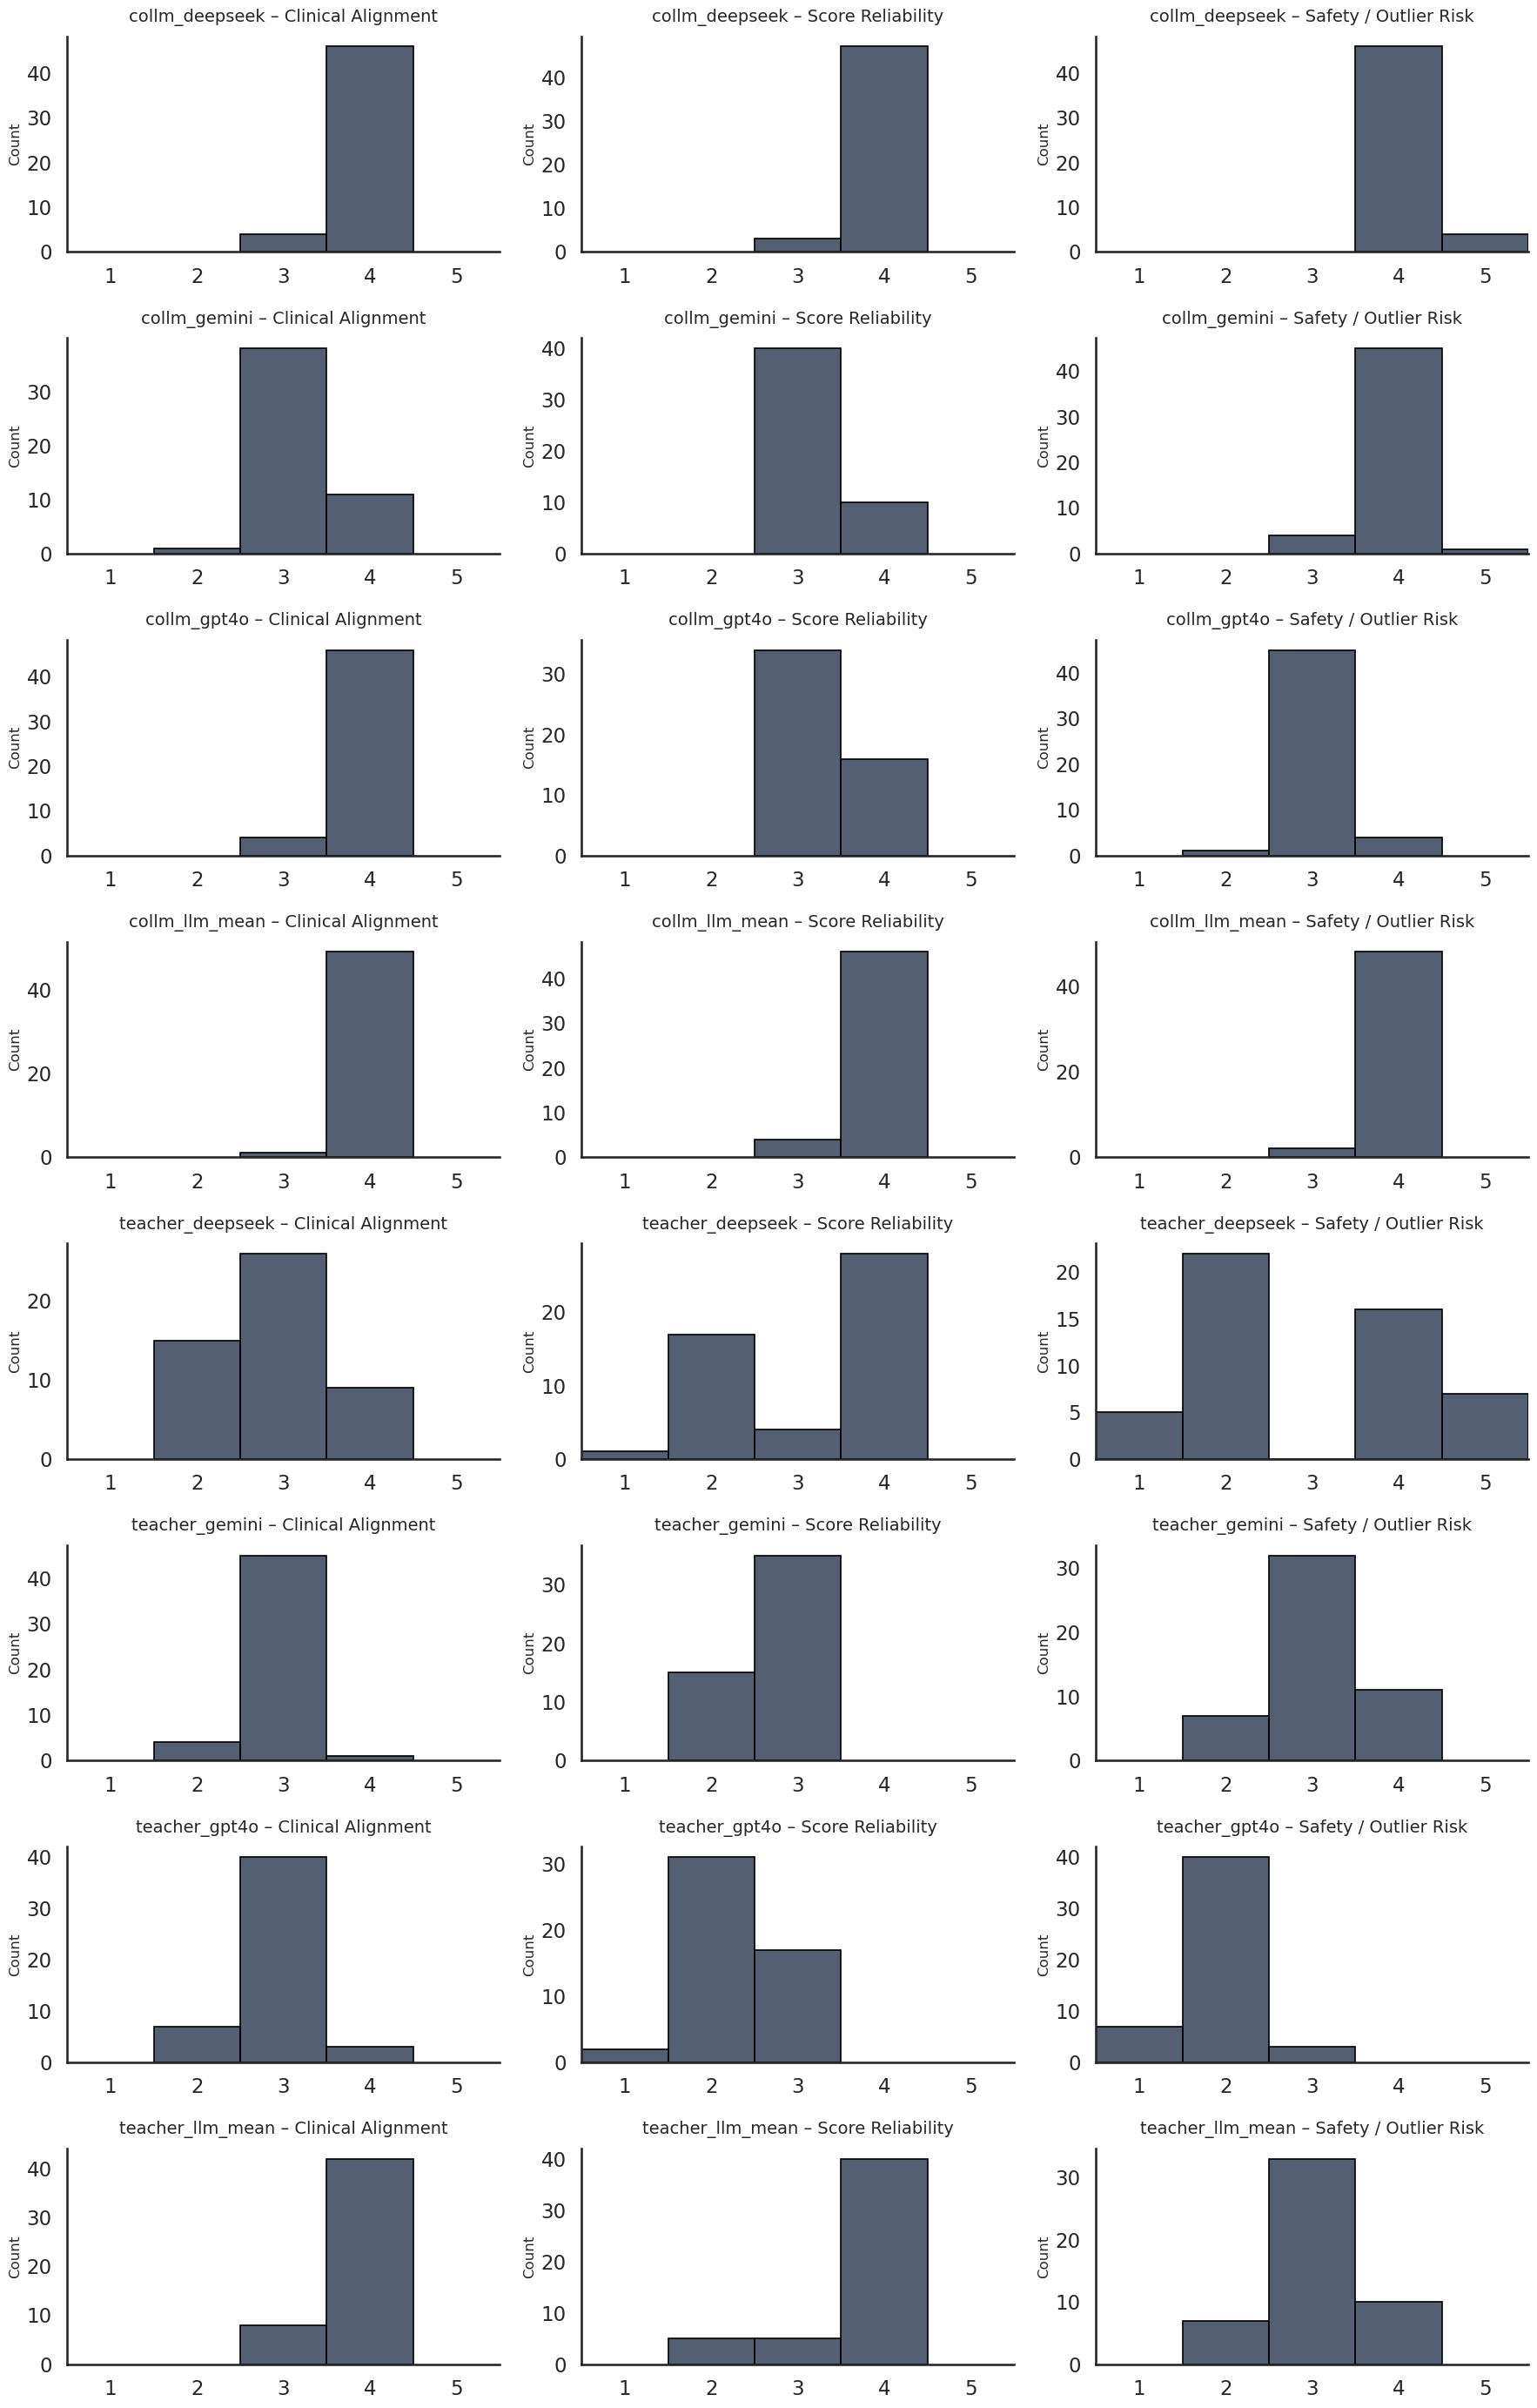

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image

# df must contain:
# model, clinical_alignment, score_reliability, safety_outlier_risk

metrics = [
    ("clinical_alignment", "Clinical Alignment"),
    ("score_reliability", "Score Reliability"),
    ("safety_outlier_risk", "Safety / Outlier Risk")
]

models = df["model"].unique()
models = sorted(models, key=lambda x: (x.startswith("teacher_"), x))  # CoLLMs first

# --- STYLE SETTINGS ---
plt.style.use("default")
sns.set_style("white")
sns.set_context("talk")

dark_color = "#1b2a41"

# Layout: 8 models × 3 metrics
fig, axes = plt.subplots(len(models), len(metrics), figsize=(18, 28))

for i, model in enumerate(models):
    model_df = df[df["model"] == model]

    for j, (metric, metric_label) in enumerate(metrics):
        ax = axes[i, j]

        sns.histplot(
            model_df[metric],
            bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
            discrete=True,
            ax=ax,
            color=dark_color,
            edgecolor="black",
            linewidth=1.2
        )

        ax.set_title(f"{model} – {metric_label}", fontsize=14, pad=12)
        ax.set_xlim(0.5, 5.5)
        ax.set_xticks([1, 2, 3, 4, 5])
        ax.set_xlabel("")
        ax.set_ylabel("Count", fontsize=12)

        sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()

# ---- STEP 1: Save as PNG (Matplotlib supports this cleanly) ----
png_path = "LLM_Judge_Histograms_temp.png"
fig.savefig(png_path, dpi=400, bbox_inches="tight")

# ---- STEP 2: Convert PNG → high quality JPG using PIL ----
jpg_path = "LLM_Judge_Histograms.jpg"
image = Image.open(png_path).convert("RGB")
image.save(jpg_path, "JPEG", quality=95)

print(f"Saved high-quality JPG to: {jpg_path}")


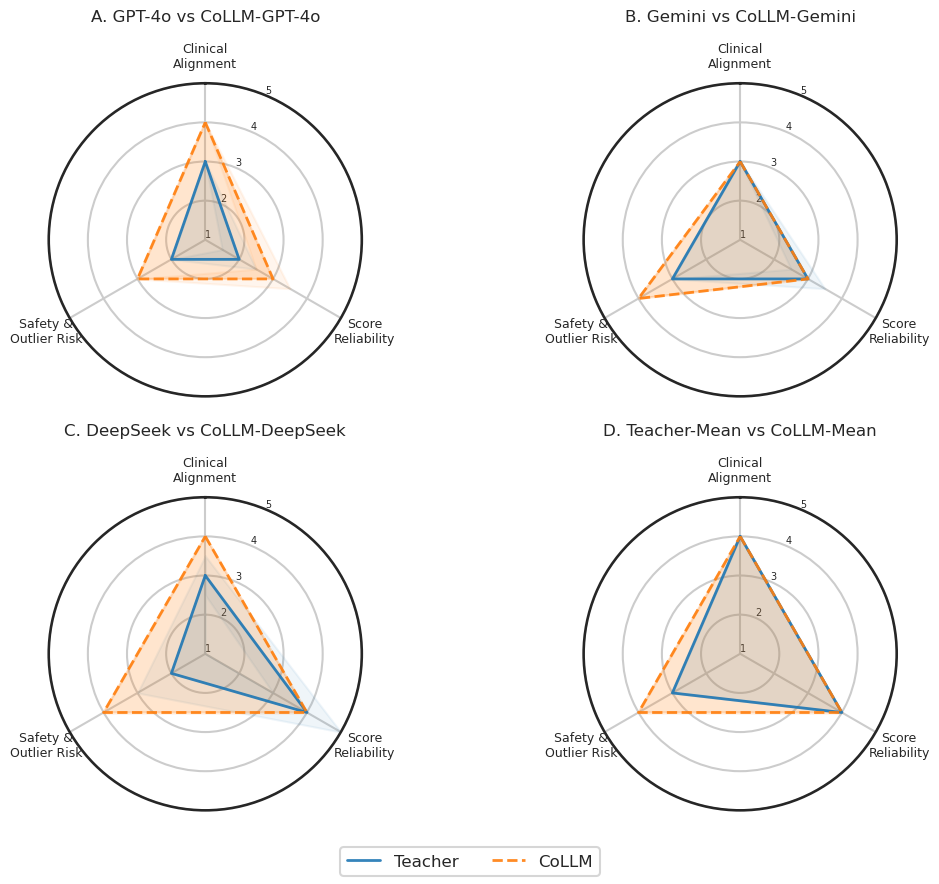

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
# REAL SCORES FROM YOUR TABLE
# ======================================================
scores = {
    "teacher_gpt4o":      [3.0, 2.0, 2.0],
    "collm_gpt4o":        [4.0, 3.0, 3.0],

    "teacher_gemini":     [3.0, 3.0, 3.0],
    "collm_gemini":       [3.0, 3.0, 4.0],

    "teacher_deepseek":   [3.0, 4.0, 2.0],
    "collm_deepseek":     [4.0, 4.0, 4.0],

    "teacher_llm_mean":   [4.0, 4.0, 3.0],
    "collm_llm_mean":     [4.0, 4.0, 4.0]
}

iqrs = {
    "teacher_gpt4o":      [0.0, 1.0, 0.0],
    "collm_gpt4o":        [0.0, 1.0, 0.0],

    "teacher_gemini":     [0.0, 1.0, 0.0],
    "collm_gemini":       [0.0, 0.0, 0.0],

    "teacher_deepseek":   [1.0, 2.0, 2.0],
    "collm_deepseek":     [0.0, 0.0, 0.0],

    "teacher_llm_mean":   [0.0, 0.0, 0.0],
    "collm_llm_mean":     [0.0, 0.0, 0.0]
}

# ======================================================
# Radar plot settings
# ======================================================
dimensions = ["Clinical\nAlignment", "Score\nReliability", "Safety &\nOutlier Risk"]
num_dims = len(dimensions)
angles = np.linspace(0, 2 * np.pi, num_dims, endpoint=False).tolist()
angles += angles[:1]

def plot_radar(ax, teacher_key, student_key, title):
    t = scores[teacher_key]
    s = scores[student_key]

    t_loop = t + t[:1]
    s_loop = s + s[:1]

    t_iqr = iqrs[teacher_key]
    s_iqr = iqrs[student_key]

    # IQR bands
    t_upper = [m + q/2 for m, q in zip(t, t_iqr)] + [t[0] + t_iqr[0]/2]
    t_lower = [m - q/2 for m, q in zip(t, t_iqr)] + [t[0] - t_iqr[0]/2]

    s_upper = [m + q/2 for m, q in zip(s, s_iqr)] + [s[0] + s_iqr[0]/2]
    s_lower = [m - q/2 for m, q in zip(s, s_iqr)] + [s[0] - s_iqr[0]/2]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(dimensions, fontsize=9)
    ax.set_ylim(1, 5)
    ax.set_yticks([1,2,3,4,5])
    ax.set_yticklabels(["1","2","3","4","5"], fontsize=7)

    # Teacher
    ax.plot(angles, t_loop, linewidth=2, alpha=0.9, label="Teacher", color="#1f77b4")
    ax.fill(angles, t_loop, alpha=0.15, color="#1f77b4")
    ax.fill_between(angles, t_lower, t_upper, alpha=0.07, color="#1f77b4")

    # Student
    ax.plot(angles, s_loop, linewidth=2, linestyle="--", alpha=0.9, label="CoLLM", color="#ff7f0e")
    ax.fill(angles, s_loop, alpha=0.20, color="#ff7f0e")
    ax.fill_between(angles, s_lower, s_upper, alpha=0.07, color="#ff7f0e")

    ax.set_title(title, fontsize=12, pad=15)

# ======================================================
# 2×2 Figure Layout
# ======================================================
fig, axes = plt.subplots(2, 2, subplot_kw={"projection": "polar"}, figsize=(11, 9))

plot_radar(axes[0,0], "teacher_gpt4o",    "collm_gpt4o",    "A. GPT-4o vs CoLLM-GPT-4o")
plot_radar(axes[0,1], "teacher_gemini",   "collm_gemini",   "B. Gemini vs CoLLM-Gemini")
plot_radar(axes[1,0], "teacher_deepseek", "collm_deepseek", "C. DeepSeek vs CoLLM-DeepSeek")
plot_radar(axes[1,1], "teacher_llm_mean", "collm_llm_mean", "D. Teacher-Mean vs CoLLM-Mean")

# Shared legend
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()
